## Анализ поведения пользователей Instacart

В проекте проводится анализ поведения пользователей онлайн-сервиса доставки продуктов Instacart.
    
**Цель анализа** — изучить структуру заказов, частоту покупок, популярные категории товаров, повторные покупки и размер корзины, а также сформировать продуктовые выводы и бизнес-гипотезы на основе полученных результатов.

### Основные выводы

- **Пользователи возвращаются регулярно**: 58.97% товарных позиций — повторные покупки, средний интервал между заказами — 11 дней с выраженным пиком на 7–8 днях (недельный цикл).
- **Спрос сосредоточен на товарах повседневного потребления**: fresh fruits, fresh vegetables, молочные продукты, хлеб, вода, снеки.
- **Пиковая нагрузка** — понедельник-вторник, около 10:00; ночные часы (3:00–5:00) практически не используются.
- **Зона наибольшего риска потери пользователя** — между 5-м и 10-м заказом (падение retention с 88% до 54%), а не в начале пути, как можно было бы предположить.
- Статистически подтверждено (хи-квадрат, корреляция Спирмена), что связь дня недели с повторностью покупки и связь интервала с размером корзины существуют, но по величине слабые — на практике не являются основными драйверами поведения.
- **Ключевые рекомендации**: развивать подписку/автозаказ на топ-категории, удерживать пользователей в окне 5–10-го заказа программами лояльности, использовать пиковые дни/часы для планирования логистики и промо. Подробности — в разделе 4.

*Технически: два обнаруженных артефакта в данных (искусственный cap на 30 днях в интервалах между заказами и на 3-м заказе в retention) учтены и объяснены по ходу анализа — они не искажают выводы.*

### 1.1. Импорт библиотек и загрузка таблиц

Для работы с данными используется `pandas`, для числовых операций — `numpy`, для визуализации — `matplotlib`.

Далее загружаются все необходимые файлы
Датасет состоит из нескольких связанных таблиц с информацией о заказах, товарах и их категориях.

Основные таблицы:

- `orders` — заказы и информация о последовательности покупок;
- `products` — товары;
- `aisles` — категории товаров;
- `departments` — крупные товарные группы;
- `prior` — товары из предыдущих заказов;
- `train` — товары из обучающей выборки.
  

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Считывание файлов
aisles = pd.read_csv('aisles.csv')
department = pd.read_csv('departments.csv')
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
prior = pd.read_csv('order_products__prior.csv')
train = pd.read_csv('order_products__train.csv')



### 1.2. Первичный осмотр данных

Перед анализом необходимо проверить структуру таблиц: размер, типы данных, пропуски и дубликаты.

In [3]:
#Создание словаря с таблицами, для удобной обработки

tables = {
    'aisles' : aisles,
    'department' : department,
    'orders' : orders,
    'products' : products,
    'prior' : prior,
    'train' : train
}


def inspect_dataframe(df, name):
    """
    Функция выполняет первичное изучение DataFrame.
    Проверяет:
    - первые строки таблицы;
    - размер данных;
    - типы данных;
    - пропущенные значения;
    - количество дубликатов.
    """

    print(f"Таблица: {name}")
    

    # Первые строки таблицы
    print("\nПервые строки:")
    display(df.head())

    # Размер таблицы
    print("\nРазмер таблицы:")
    print(f"{df.shape[0]:,} строк × {df.shape[1]} столбцов")

    # Типы данных
    print("\nТипы данных:")
    display(df.dtypes.to_frame("Тип данных"))

    # Пропущенные значения
    print("\nПропущенные значения:")
    missing = df.isnull().sum()

    display(
        missing[missing > 0]
        .to_frame("Количество пропусков")
    )

    # Дубликаты
    print("\nКоличество дубликатов:")
    print(f"{df.duplicated().sum():,}")

    print("\n")


# Проверка всей таблицы датасета

for name, table in tables.items():
    inspect_dataframe(table, name)

Таблица: aisles

Первые строки:


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



Размер таблицы:
134 строк × 2 столбцов

Типы данных:


,Тип данных
aisle_id,int64
aisle,str



Пропущенные значения:


...


Размер таблицы:
1,384,617 строк × 4 столбцов

Типы данных:


,Тип данных
order_id,int64
product_id,int64
add_to_cart_order,int64
reordered,int64



Пропущенные значения:


,Количество пропусков



Количество дубликатов:
0





В результате было выявлено, что в таблице orders есть пропущенные значения в столбце **days_since_prior_order**. 
Данный столбец показывает количество дней, прошедших с момента предыдущего заказа пользователя. Для первого заказа пользователя значение невозможно рассчитать, так как предыдущий заказ отсутствует.
Нужно сдеалть дополнительную проверку:

In [4]:
# Проверяем, какие номера заказов имеют пропуски

orders[orders["days_since_prior_order"].isnull()]["order_number"].value_counts()

order_number
1    206209
Name: count, dtype: int64

    Дополнительная проверка показала, что все пропущенные значения относятся к заказам с `order_number = 1`.
Таким образом, пропуски являются не ошибкой данных, а логическим отсутствием значения.
Удаление таких строк может привести к потере информации о первых заказах пользователей, поэтому данные значения будут сохранены без изменений.

### 1.3. Создание итоговой аналитической таблицы

Для дальнейшего анализа было выполнено объединение таблиц:

- `orders` — информация о пользователях и заказах;
- `prior` — информация о товарах в заказах;
- `products` — информация о товарах;
- `aisles` — категории товаров;
- `departments` — отделы товаров.


In [4]:
# Объединение таблиц

df = (
    orders
    .merge(prior, on="order_id", how="inner")
    .merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(department, on="department_id", how="left")
)


# Размер итоговой таблицы

print(
    f"Размер данных: {df.shape[0]:,} строк × {df.shape[1]} столбцов"
)


# Первые строки

display(df.head())


# Общая информация

df.info()

Размер данных: 32,434,489 строк × 15 столбцов


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2539329,1,prior,1,2,8,NaN,196,1,0,Soda,77,7,soft drinks,beverages
1,2539329,1,prior,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs
2,2539329,1,prior,1,2,8,NaN,12427,3,0,Original Beef Jerky,23,19,popcorn jerky,snacks
3,2539329,1,prior,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks
4,2539329,1,prior,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household


<class 'pandas.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
 7   product_id              int64  
 8   add_to_cart_order       int64  
 9   reordered               int64  
 10  product_name            str    
 11  aisle_id                int64  
 12  department_id           int64  
 13  aisle                   str    
 14  department              str    
dtypes: float64(1), int64(10), str(4)
memory usage: 3.6 GB


После объединения нужно провести проверку на наличие пропусков и дубликатов, чтобы убедиться, что объединение таблиц прошло корректно.

In [7]:
# Пропуски

missing = df.isnull().sum()


display(
    missing[missing > 0]
    .to_frame("Количество пропусков")
)


# Дубликаты

print(
    "Количество дубликатов:",
    df.duplicated().sum()
)

,Количество пропусков
days_since_prior_order,2078068


Количество дубликатов: 0


## 2. Исследовательский анализ данных (EDA)
 На этом этапе необходимо проанализировать основные особенности поведения пользователей: время совершения заказов, интервалы между покупками, популярные категории, повторные покупки и размер корзины.

### 2.1. Основные показатели датасета

In [8]:
# Основные показатели датасета

summary = {
    "Количество пользователей": df["user_id"].nunique(),
    "Количество заказов": df["order_id"].nunique(),
    "Количество товаров": df["product_id"].nunique(),
    "Количество категорий": df["aisle"].nunique(),
    "Количество отделов": df["department"].nunique()
}

pd.DataFrame(
    summary.items(),
    columns=["Показатель", "Значение"]
)

,Показатель,Значение
0,Количество пользователей,206209
1,Количество заказов,3214874
2,Количество товаров,49677
3,Количество категорий,134
4,Количество отделов,21


### 2.2. В какие дни пользоватлеь чаще всего делает заказ

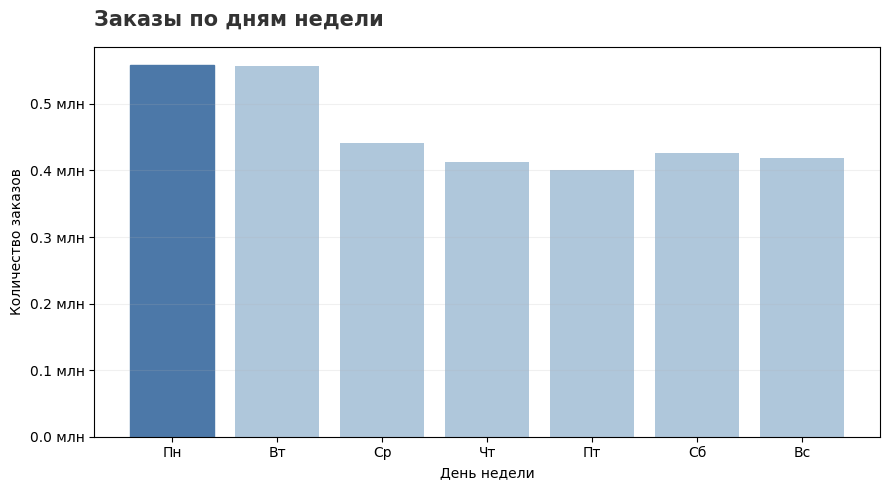

In [5]:
orders_by_day = (
    df.groupby("order_dow")["order_id"]
      .nunique()
      .sort_index()
)

days = {
    0: "Пн",
    1: "Вт",
    2: "Ср",
    3: "Чт",
    4: "Пт",
    5: "Сб",
    6: "Вс"
}

orders_by_day.index = orders_by_day.index.map(days)

peak_day = orders_by_day.idxmax()
peak_value = orders_by_day.max()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    orders_by_day.index,
    orders_by_day.values,
    color="#AFC7DB",
    edgecolor="none"
)

# Выделяем день с максимальным количеством заказов
peak_index = list(orders_by_day.index).index(peak_day)
bars[peak_index].set_color("#4C78A8")

ax.set_title(
    "Заказы по дням недели",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333",
    pad=15
)

ax.set_xlabel("День недели")
ax.set_ylabel("Количество заказов")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1e6:.1f} млн")
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

**Пик покупательской активности наблюдается в понедельник и вторник**, тогда как в конце недели количество заказов ниже. Это может быть полезно учитывать при планировании промо-активностей и операционной нагрузки.

### 2.3 Распределение заказов по часам
Анализ распределения заказов по часам позволяет определить время суток, когда пользователи наиболее активно совершают покупки.

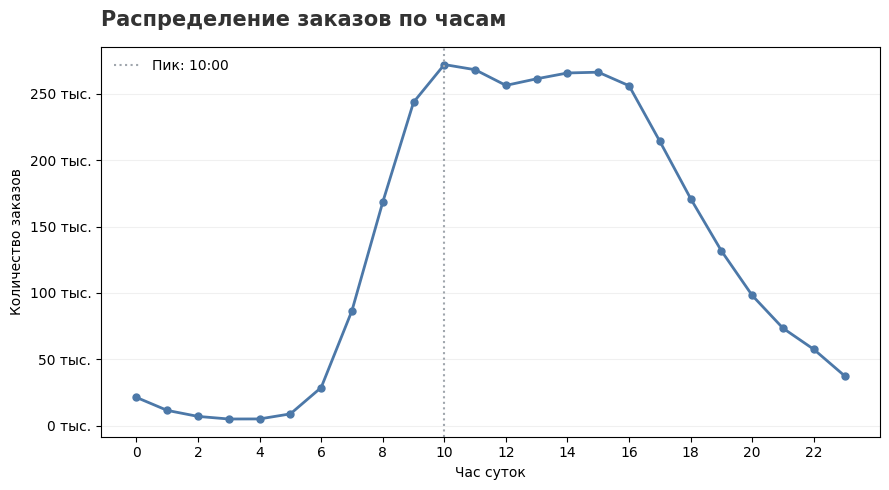

In [6]:
# Количество уникальных заказов по часам
orders_by_hour = (
    df.groupby("order_hour_of_day")["order_id"]
      .nunique()
      .sort_index()
)

peak_hour = orders_by_hour.idxmax()

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    color="#4C78A8",
    marker="o",
    markersize=5,
    linewidth=2
)

# Отмечаем пиковый час
ax.axvline(
    peak_hour,
    color="#A0A6AD",
    linestyle=":",
    linewidth=1.5,
    label=f"Пик: {peak_hour}:00"
)

ax.set_title(
    "Распределение заказов по часам",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333",
    pad=15
)

ax.set_xlabel("Час суток")
ax.set_ylabel("Количество заказов")

ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1e3:.0f} тыс.")
)

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

Наибольшая активность наблюдается в первой половине дня, тогда как минимальное количество заказов приходится на ночные часы. Пиковое значение достигается в **10:00**. Минимум приходится на **3:00–5:00**

### 2.4. Интервал между заказами
   Интервал между заказами показывает, с какой периодичностью пользователи возвращаются за следующей покупкой. 

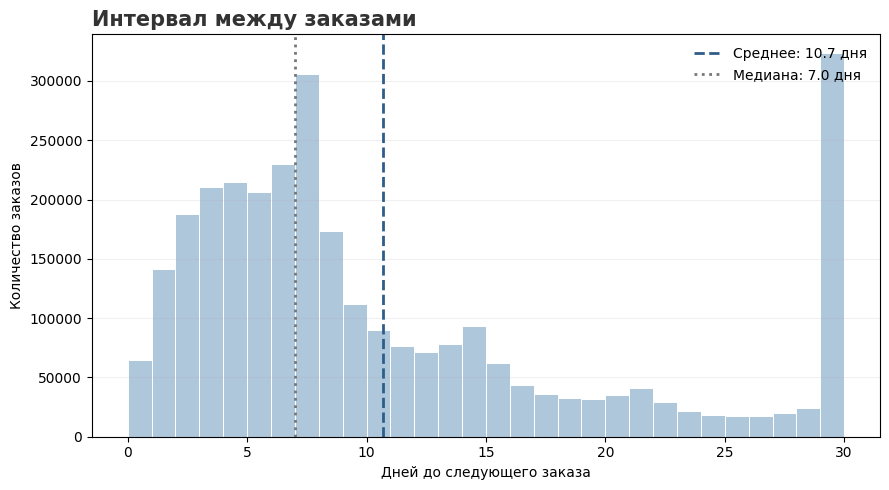

In [8]:
days_between_orders = (
    df[["order_id", "days_since_prior_order"]]
    .drop_duplicates()
    .dropna()
)

mean_days = days_between_orders["days_since_prior_order"].mean()
median_days = days_between_orders["days_since_prior_order"].median()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    days_between_orders["days_since_prior_order"],
    bins=30,
    color="#AFC7DB",
    edgecolor="white",
    linewidth=0.7
)

# Среднее
ax.axvline(
    mean_days,
    color="#2F5D8A",
    linestyle="--",
    linewidth=2,
    label=f"Среднее: {mean_days:.1f} дня"
)

# Медиана
ax.axvline(
    median_days,
    color="#777777",
    linestyle=":",
    linewidth=2,
    label=f"Медиана: {median_days:.1f} дня"
)

ax.set_title(
    "Интервал между заказами",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333"
)

ax.set_xlabel("Дней до следующего заказа")
ax.set_ylabel("Количество заказов")

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.legend(
    frameon=False,
    loc="upper right"
)


plt.tight_layout()
plt.show()

Распределение интервала между заказами имеет выраженный пик около **7–8 дней**, что указывает на наличие недельного цикла повторных покупок. 
Средний интервал между заказами составляет **11,11 дня**, то есть в среднем пользователи возвращаются за следующей покупкой примерно через полторы недели. При этом распределение интервалов неоднородное: часть пользователей совершает повторные покупки через короткие промежутки времени, тогда как у другой части между заказами проходит значительно больше времени.

На графике также заметно большое количество заказов с интервалом **30 дней**. 


### 2.5. Самые популярные категории товаров
   Анализ категорий позволяет определить, какие группы товаров формируют основной объём покупок. 

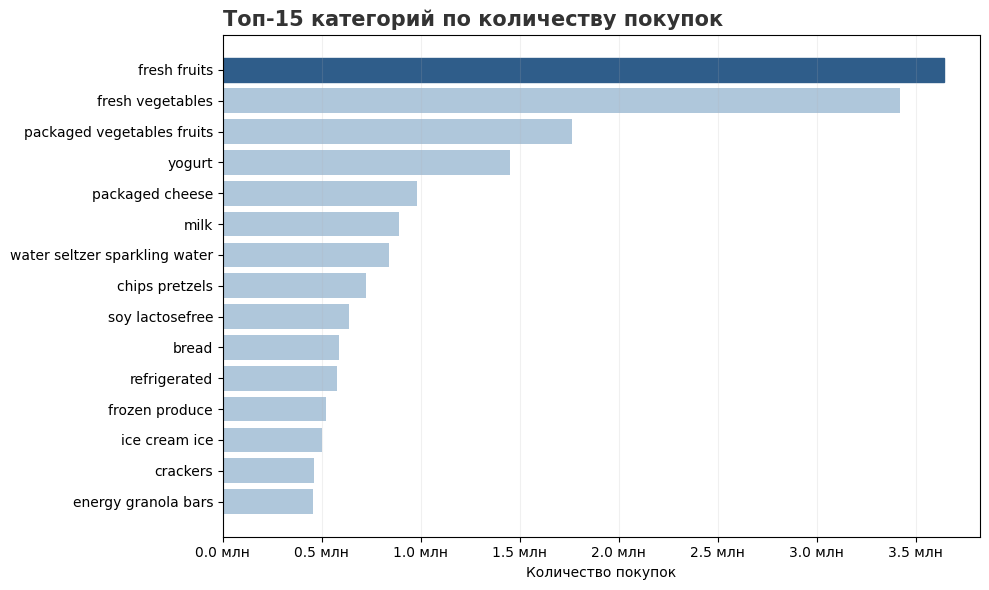

In [9]:

top_aisles = (
    df["aisle"]
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_aisles.index,
    top_aisles.values,
    color="#AFC7DB",
    edgecolor="none"
)

# Выделение категории-лидера
bars[-1].set_color("#2F5D8A")

ax.set_title(
    "Топ-15 категорий по количеству покупок",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333"
)

ax.set_xlabel("Количество покупок")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1e6:.1f} млн")
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

Наиболее популярными категориями являются **fresh fruits** и **fresh vegetables**, которые заметно опережают остальные категории по количеству покупок. В топ также входят молочные продукты, хлеб, вода и снеки — товары регулярного повседневного спроса.
Это показывает, что основную часть покупок на Instacart формируют продукты первой необходимости и товары с регулярным спросом.

### 2.6. Повторные покупки
    Нужно определить, какая доля повторных покупок

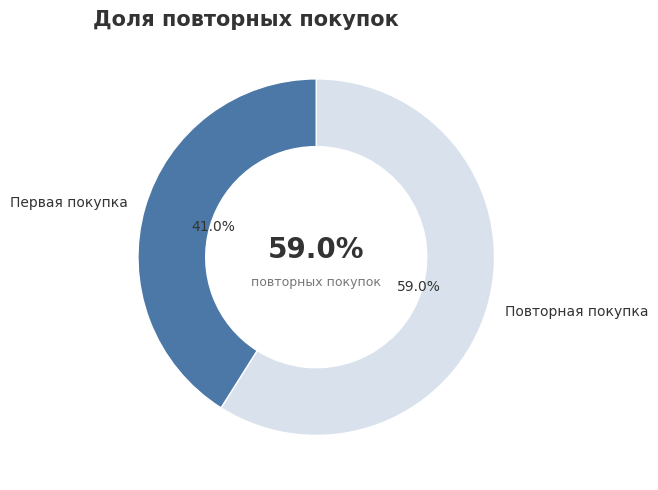

In [19]:
repeat_rate = (
    df["reordered"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={
        0: "Первая покупка",
        1: "Повторная покупка"
    })
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.pie(
    repeat_rate,
    labels=repeat_rate.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=["#D9E2EC", "#4C78A8"],
    wedgeprops=dict(
        width=0.38,
        edgecolor="white"
    ),
    textprops=dict(
        color="#333333",
        fontsize=10
    )
)

# Доля повторных покупок в центре
ax.text(
    0,
    0.04,
    f"{repeat_rate['Повторная покупка']:.1f}%",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#333333"
)

ax.text(
    0,
    -0.14,
    "повторных покупок",
    ha="center",
    va="center",
    fontsize=9,
    color="#777777"
)

ax.set_title(
    "Доля повторных покупок",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333"
)

plt.tight_layout()
plt.show()

Высокая доля повторных покупок указывает на наличие регулярного спроса на привычные товары.

### 2.7. Товары с наибольшим количеством повторных покупок
   Нужно определить товары, которые пользователи чаще всего приобретают повторно.

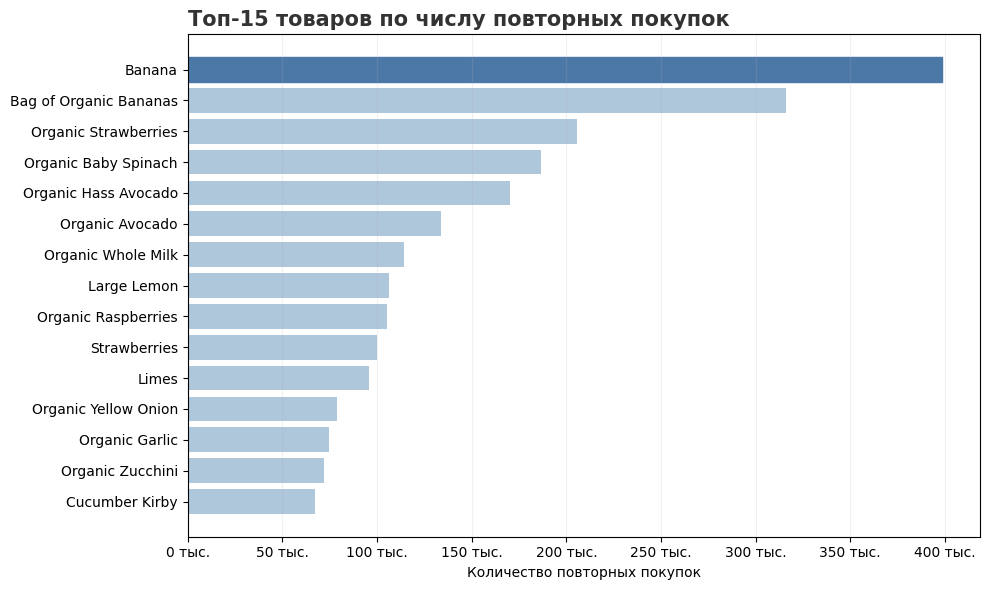

In [22]:
top_repeat_products = (
    df[df["reordered"] == 1]["product_name"]
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_repeat_products.index,
    top_repeat_products.values,
    color="#AFC7DB",
    edgecolor="none"
)

# Товар с максимальным числом повторных покупок
bars[-1].set_color("#4C78A8")

ax.set_title(
    "Топ-15 товаров по числу повторных покупок",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333"
)

ax.set_xlabel("Количество повторных покупок")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1e3:.0f} тыс.")
)

ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

Анализ показывает, что повторные покупки в значительной степени формируются **за счёт регулярно приобретаемых продуктов**, которые пользователи возвращают в корзину снова и снова. Особенно заметно присутствие свежих продуктов среди лидеров, что согласуется с результатами анализа наиболее популярных категорий.
При этом количество повторных покупок отражает абсолютное число повторных заказов, поэтому **оно зависит не только от склонности товара к повторной покупке, но и от его общей популярности**. Чтобы определить, какие товары действительно имеют наиболее высокий уровень повторного спроса, дополнительно стоит сравнить количество повторных покупок с общим количеством покупок каждого товара.

### 2.8. Среднее количество товаров в заказе

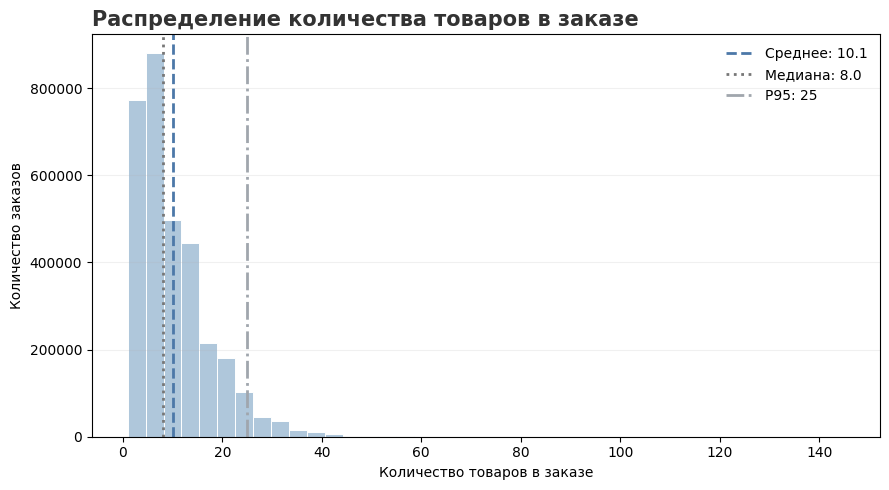

In [23]:
items_per_order = (
    df.groupby("order_id")["product_id"]
      .count()
)

mean_items = items_per_order.mean()
median_items = items_per_order.median()
p95_items = items_per_order.quantile(0.95)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    items_per_order,
    bins=40,
    color="#AFC7DB",
    edgecolor="white",
    linewidth=0.7
)

# Среднее
ax.axvline(
    mean_items,
    color="#4C78A8",
    linestyle="--",
    linewidth=2,
    label=f"Среднее: {mean_items:.1f}"
)

# Медиана
ax.axvline(
    median_items,
    color="#777777",
    linestyle=":",
    linewidth=2,
    label=f"Медиана: {median_items:.1f}"
)

# 95-й перцентиль
ax.axvline(
    p95_items,
    color="#A0A6AD",
    linestyle="-.",
    linewidth=2,
    label=f"P95: {p95_items:.0f}"
)

ax.set_title(
    "Распределение количества товаров в заказе",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333"
)

ax.set_xlabel("Количество товаров в заказе")
ax.set_ylabel("Количество заказов")

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.legend(frameon=False)

# Обрезаем пустой хвост распределения для читаемости
ax.set_xlim(0, items_per_order.quantile(0.995))

plt.tight_layout()
plt.show()

Распределение количества товаров в заказе имеет выраженную правую асимметрию: основная часть заказов содержит относительно небольшое количество товаров, при этом небольшая доля заказов значительно крупнее.
Медианный размер корзины составляет около **6–7 товаров**, а среднее значение выше медианы из-за крупных заказов. 95-й перцентиль находится примерно в диапазоне **25–30 товаров**, тогда как заказы более чем с 40 товарами встречаются редко.

### 2.9. Статистическая проверка гипотез

Описательные метрики выше показывают наблюдаемые различия и закономерности (разная активность по дням недели, разный интервал между заказами). Проверим две из них статистически: не являются ли эти различия случайными.

**Гипотеза 1.** Зависит ли вероятность того, что товар — повторная покупка (`reordered = 1`), от дня недели, в который сделан заказ?

- H0: доля повторных покупок не зависит от дня недели.
- H1: доля повторных покупок зависит от дня недели.

Так как обе переменные категориальные, используем **критерий хи-квадрат** на независимость.

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["order_dow"], df["reordered"])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi2 = {chi2:.2f}")
print(f"p-value = {p_value:.4f}")
print(f"Степени свободы = {dof}")

Chi2 = 10349.36 при p-value < 0.0001 — нулевая гипотеза отклоняется: статистическая связь между днём недели и вероятностью повторной покупки есть. Однако при таком большом объёме выборки (миллионы строк) даже очень слабые, практически незначимые различия становятся статистически значимыми — поэтому важно оценивать не только p-value, но и величину эффекта. Разброс доли повторных покупок по дням недели на практике небольшой (единицы процентных пунктов), и с точки зрения бизнеса день недели сам по себе не является значимым фактором, определяющим повторность покупки — статистическая значимость здесь не равна практической важности.

**Гипотеза 2.** Связан ли интервал с момента предыдущего заказа (`days_since_prior_order`) с размером текущего заказа — то есть запасаются ли пользователи впрок, если давно не заказывали?

- H0: связи между интервалом и размером заказа нет (корреляция ≈ 0).
- H1: связь есть.

Так как распределение размера заказа несимметрично (правая асимметрия, см. 2.8), используем **корреляцию Спирмена**, а не Пирсона.

In [ ]:
from scipy.stats import spearmanr

order_level = (
    df.groupby("order_id")
      .agg(
          order_size=("product_id", "count"),
          days_since_prior_order=("days_since_prior_order", "first")
      )
      .dropna()
)

corr, p_value = spearmanr(
    order_level["days_since_prior_order"],
    order_level["order_size"]
)

print(f"Корреляция Спирмена = {corr:.3f}")
print(f"p-value = {p_value:.4f}")

Корреляция Спирмена = 0.102 при p-value < 0.0001 — связь статистически значима, но по величине слабая (коэффициент намного ближе к 0, чем к 1). Это означает, что связь между давностью предыдущего заказа и размером текущего действительно есть — пользователи, дольше не заказывавшие, в среднем берут чуть больше товаров, — но она объясняет лишь небольшую часть вариативности размера корзины. Гипотеза «запасается впрок» подтверждается статистически, но не является основным фактором, определяющим размер заказа: на него сильнее влияют другие обстоятельства (тип домохозяйства, привычная частота похода за покупками и т.д.), которые в этом датасете не отражены.

## 3. Продуктовые метрики
На этом этапе анализируем основные особенности поведения пользователей: время совершения заказов, интервалы между покупками, популярные категории, повторные покупки и размер корзины.

### 3.1. Доля повторно заказанных товарных позиций

Метрика показывает, какая доля товарных позиций в заказах была ранее приобретена пользователем.


In [38]:
# Repeat Purchase Rate

repeat_purchase_rate = df["reordered"].mean() * 100

print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")

Repeat Purchase Rate: 58.97%


Высокая доля повторных покупок показывает, что значительная часть заказов формируется за счёт товаров, которые пользователи уже приобретали ранее.

### 3.2. Среднее количество товаров в заказе

Метрика показывает среднее количество товаров, приобретаемых пользователями за один заказ.

In [39]:
# Среднее количество товаров в заказе

avg_items_per_order = (
    df.groupby("order_id")["product_id"]
      .count()
      .mean()
)

print(f"Среднее количество товаров в заказе: {avg_items_per_order:.2f}")

Среднее количество товаров в заказе: 10.09


Средний размер заказа составляет 10.09 товара, однако медиана находится примерно на уровне 6–7 товаров. Разница между средним и медианой объясняется наличием относительно небольшого количества крупных заказов, которые увеличивают среднее значение.

### 3.3. Среднее количество заказов на пользователя
Метрика показывает средний размер корзины пользователя в рамках одного заказа.

In [40]:
# Среднее количество заказов на пользователя

avg_orders_per_user = (
    orders.groupby("user_id")["order_number"]
          .max()
          .mean()
)

print(f"Среднее количество заказов на пользователя: {avg_orders_per_user:.2f}")

Среднее количество заказов на пользователя: 16.59


В среднем на одного пользователя приходится 16.59 заказа за период наблюдения. Это показывает, что пользователи в данных совершают покупки неоднократно, а не ограничиваются одним заказом.
При этом среднее значение не означает, что каждый пользователь совершает около 17 заказов: распределение количества заказов между пользователями может существенно различаться.

### 3.4. Средний интервал между заказами

Метрика показывает, через сколько дней пользователь в среднем возвращается за новой покупкой.

In [41]:
# Средний интервал между заказами

avg_days_between_orders = (
    orders["days_since_prior_order"]
    .mean()
)

print(f"Средний интервал между заказами: {avg_days_between_orders:.2f} дней")

Средний интервал между заказами: 11.11 дней


Средний интервал между заказами составляет 11.11 дня. Это показывает, что пользователи в среднем возвращаются за следующим заказом примерно через полторы недели.

### 3.5. Среднее количество уникальных товаров на пользователя

Метрика показывает, сколько различных товаров в среднем покупает один пользователь.

In [44]:
# Среднее количество уникальных товаров на пользователя

avg_unique_products = (
    df.groupby("user_id")["product_id"]
      .nunique()
      .mean()
)

print(f"Среднее количество уникальных товаров на пользователя: {avg_unique_products:.2f}")

Среднее количество уникальных товаров на пользователя: 64.54


В среднем на одного пользователя приходится 64.54 уникальных товара за весь период наблюдения. Это показывает, что пользователи формируют достаточно разнообразные корзины, несмотря на высокую долю повторных покупок.
Таким образом, поведение пользователей сочетает регулярное повторение привычных товаров с достаточно широким ассортиментом приобретаемых позиций.

Соберём рассчитанные показатели в одну таблицу для удобного сравнения.

In [46]:
# Сводная таблица продуктовых метрик

metrics = pd.DataFrame({
    "Метрика": [
        "Repeat Purchase Rate",
        "Среднее количество товаров в заказе",
        "Среднее количество заказов на пользователя",
        "Средний интервал между заказами",
        "Среднее количество уникальных товаров на пользователя"
    ],
    "Значение": [
        f"{repeat_purchase_rate:.2f}%",
        f"{avg_items_per_order:.2f}",
        f"{avg_orders_per_user:.2f}",
        f"{avg_days_between_orders:.2f} дней",
        f"{avg_unique_products:.2f}"
    ]
})

display(metrics)

,Метрика,Значение
0,Repeat Purchase Rate,58.97%
1,Среднее количество товаров в заказе,10.09
2,Среднее количество заказов на пользователя,16.59
3,Средний интервал между заказами,11.11 дней
4,Среднее количество уникальных товаров на польз...,64.54


### 3.6. Retention пользователей по номеру заказа

Дополнительно оценим, какая доля пользователей доходит до определённого по счёту заказа (2-го, 5-го, 10-го и т.д.). Это позволяет оценить масштаб оттока после первых заказов и дополняет метрику Repeat Purchase Rate конкретной цифрой удержания.

In [11]:
# Максимальный номер заказа на пользователя
max_order_per_user = orders.groupby("user_id")["order_number"].max()

total_users = max_order_per_user.shape[0]

# Доля пользователей, доходящих хотя бы до N-го заказа
milestones = [2, 3, 5, 10, 15, 20]
retention = {
    n: (max_order_per_user >= n).sum() / total_users * 100
    for n in milestones
}

retention_df = pd.DataFrame({
    "Номер заказа": [f"Заказ №{n}" for n in milestones],
    "Доля пользователей, %": [round(v, 2) for v in retention.values()]
})

display(retention_df)

,Номер заказа,"Доля пользователей, %"
0,Заказ №2,100.00
1,Заказ №3,100.00
2,Заказ №5,88.37
3,Заказ №10,53.70
4,Заказ №15,36.41
5,Заказ №20,26.15


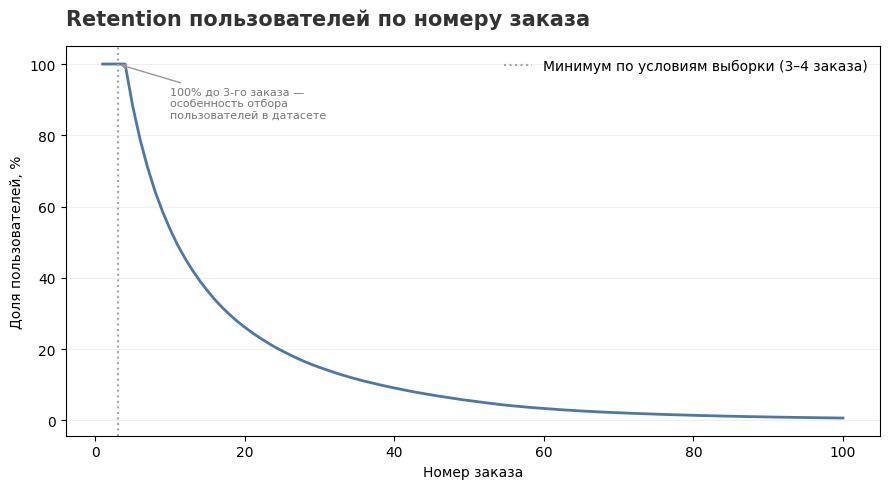

In [12]:
# График retention curve по всем номерам заказа
max_n = int(max_order_per_user.max())
order_range = range(1, max_n + 1)
retention_curve = [
    (max_order_per_user >= n).sum() / total_users * 100
    for n in order_range
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    list(order_range),
    retention_curve,
    color="#4C78A8",
    linewidth=2
)

# Граница гарантированного минимума заказов в выборке Instacart
ax.axvline(
    3,
    color="#A0A6AD",
    linestyle=":",
    linewidth=1.5,
    label="Минимум по условиям выборки (3–4 заказа)"
)

ax.annotate(
    "100% до 3-го заказа —\nособенность отбора\nпользователей в датасете",
    xy=(3, 100),
    xytext=(10, 85),
    fontsize=8,
    color="#777777",
    ha="left",
    arrowprops=dict(arrowstyle="->", color="#999999", lw=1)
)

ax.set_title(
    "Retention пользователей по номеру заказа",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#333333",
    pad=15
)

ax.set_xlabel("Номер заказа")
ax.set_ylabel("Доля пользователей, %")

ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

До 3-го заказа включительно доля пользователей держится на уровне 100%, после чего кривая начинает плавно снижаться: 88.37% доходят до 5-го заказа, 53.70% — до 10-го, 36.41% — до 15-го, 26.15% — до 20-го.

Плоский участок в начале — не признак отсутствия оттока, а особенность формирования датасета: в Instacart Market Basket Analysis в выборку включались только пользователи с историей не менее 4 заказов (так по условиям исходного соревнования на Kaggle), поэтому у каждого пользователя в данных гарантированно есть минимум 3–4 заказа. Настоящую динамику оттока в начале пути пользователя по этим данным оценить нельзя — она отфильтрована на этапе сбора выборки.

Содержательный вывод касается участка **после** гарантированного минимума: снижение с 88% (5-й заказ) до 54% (10-й заказа) — заметное падение примерно на 34 п.п. за 5 заказов, тогда как дальше, с 10-го по 20-й заказ, падение более плавное (с 54% до 26%). Это говорит о том, что зона наибольшего риска потери пользователя — это период между 5-м и 10-м заказом, а не самое начало взаимодействия с сервисом. Именно на удержание в этом окне стоит в первую очередь направлять программы лояльности и персонализированные предложения.

## 4. Бизнес-рекомендации

На основе проведённого анализа сформулированы ключевые находки и рекомендации, сгруппированные по направлениям: удержание пользователей, работа с ассортиментом, операционное планирование и персонализация.

### 4.1. Ключевые находки

| Метрика | Значение | Вывод |
|---|---|---|
| Repeat Purchase Rate | 58.97% | Более половины позиций в заказах — повторные покупки привычных товаров |
| Среднее число товаров в заказе | 10. (медиана 6–7) | Типичная корзина небольшая, но есть доля крупных заказов |
| Среднее число заказов на пользователя | 17 | Пользователи возвращаются многократно, отток есть, но база лояльна |
| Средний интервал между заказами | 11 дня (пик 7–8 дней) | Виден недельный цикл повторных покупок |
| Среднее число уникальных товаров на пользователя | 65 | Корзины разнообразны, несмотря на высокую повторность |
| Пиковые дни заказов | Понедельник, вторник | Начало недели — основная нагрузка на сервис |
| Пиковый час заказов | ~10:00 (минимум 3:00–5:00) | Основная активность — первая половина дня |
| Топ-категории | fresh fruits, fresh vegetables, dairy, bread, water, snacks | Спрос сосредоточен на товарах повседневного потребления |
| Retention по номеру заказа | 100% до 3-го заказа (артефакт выборки Kaggle), затем 88% → 54% → 26% (заказы 5/10/20) | Основная зона риска потери пользователя — между 5-м и 10-м заказом |

### 4.2. Рекомендации

**1. Стимулировать повторные покупки через автозаказ и напоминания**

Раз почти 59% позиций — повторные, а между заказами наблюдается устойчивый недельный цикл (пик 7–8 дней), стоит внедрить функцию «быстрый повтор заказа» и push/email-напоминания, приуроченные к 7–8-му дню с момента последней покупки конкретного товара или всей корзины. Это снижает трение при повторной покупке и удерживает пользователя в привычном ритме.

**1а. Сфокусировать удержание на окне между 5-м и 10-м заказом**

Retention-кривая показывает наиболее заметное падение именно в этом окне (с 88% до 54%), а не в начале пути пользователя. Программы лояльности, персональные скидки и «вовлекающие» механики (бонусы за серию заказов, напоминания о разнообразии ассортимента) стоит приурочивать не к первому заказу, а к моменту, когда пользователь приближается к 5–10-му заказу — это точка, где решается, станет ли он по-настоящему регулярным клиентом.

**2. Развивать подписку (subscription/auto-reorder) на топ-категории**

Категории fresh fruits, fresh vegetables, молочные продукты, хлеб, вода и снеки — товары регулярного спроса. Для них имеет смысл предложить подписку с автоматическим повтором заказа и небольшой скидкой за предсказуемость спроса — это выгодно и пользователю, и сервису (снижение стоимости привлечения повторной покупки, более точное планирование закупок).

**3. Увеличивать средний размер корзины (AOV)**

Медианная корзина — всего 6–7 товаров, при этом среднее (10.09) поднимается за счёт немногих крупных заказов. Точки роста: cross-sell сопутствующих товаров из топ-категорий («к этому товару часто покупают»), порог бесплатной доставки чуть выше медианной корзины, персональные подборки на основе истории заказов.

**4. Использовать пики активности для операционного и маркетингового планирования**

Понедельник-вторник и время около 10:00 — периоды максимальной нагрузки. Рекомендуется:
- заранее пополнять склад товарами топ-категорий к началу недели;
- усиливать поддержку курьеров/логистики в пиковые часы;
- планировать рассылки и промо-акции на воскресенье вечером — понедельник утро, чтобы попасть в момент принятия решения о покупке;
- в ночные часы (3:00–5:00) и в выходные снижать интенсивность маркетинговых кампаний как менее эффективную.

**5. Персонализировать напоминания и рекомендации на основе истории**

Пользователи в среднем покупают 64.54 уникальных товара — это говорит о разнообразии, но с явным ядром повторяющихся позиций. Рекомендательная система «мои обычные товары» / «пора купить снова» на основе истории заказов конкретного пользователя (а не общих топ-категорий) может повысить конверсию в повторный заказ сильнее, чем общие акции.

**6. Сегментировать пользователей по частоте заказов**

Среднее число заказов на пользователя (16.59) не означает, что все пользователи одинаково активны — распределение может быть неравномерным. Стоит выделить сегменты (например, «разовые», «нерегулярные», «постоянные») и работать с каждым отдельно: для разовых — welcome-скидка на второй заказ, для нерегулярных — win-back кампании, для постоянных — программа лояльности.

### 4.3. Метрики для отслеживания эффекта

При внедрении рекомендаций стоит отслеживать:
- Repeat Purchase Rate (динамика после запуска напоминаний/подписки);
- средний размер корзины (AOV) и его изменение после внедрения cross-sell;
- долю пользователей с активной подпиской/автозаказом;
- изменение среднего интервала между заказами по сегментам;
- churn-rate по сегментам (разовые / нерегулярные / постоянные пользователи).